## Libraries and Installation

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ls /content/gdrive/MyDrive/deep_text/

Mounted at /content/gdrive
Pranav_LSTM2.ipynb  sherlockholmes.txt
Pranav_LSTM.ipynb   text_generation_sherlock_rnn_temp_exp.ipynb
RNNTorch.ipynb	    TokenLSTM.ipynb


In [2]:
pip install pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 110.9 MB/s eta 0:00:00


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import platform
import time
import pathlib
import os
import glob
from spellchecker import SpellChecker

print('Python version:', platform.python_version())
print('Tensorflow version:', tf.__version__)
print('Keras version:', tf.keras.__version__)

from collections import Counter
import tempfile
import re

Python version: 3.11.12
Tensorflow version: 2.18.0
Keras version: 3.8.0


## Data

In [4]:
# TEMP_CHECKPOINT_DIR = os.path.join('/tmp', 'lstm_checkpoints')
# os.makedirs(TEMP_CHECKPOINT_DIR, exist_ok=True)
checkpoint_dir = 'tmp/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Checkpoint directory created at: {checkpoint_dir}")
file_path = '/content/gdrive/MyDrive/deep_text/sherlockholmes.txt'
print(f"file path: {file_path}")

Checkpoint directory created at: tmp/checkpoints
file path: /content/gdrive/MyDrive/deep_text/sherlockholmes.txt


### Load Data

In [5]:
with open(file_path, 'r', encoding='utf-8') as f:
    text = f.read()
print(f"data has been read successfully...")
print(f"Loaded {len(text)} characters.")

data has been read successfully...
Loaded 561801 characters.


### Data Exploration

In [6]:
print(f"first 250 characters...")
print(f"{text[:250]}")

first 250 characters...
The Adventures of Sherlock Holmes

by Arthur Conan Doyle

I. A SCANDAL IN BOHEMIA


I.

To Sherlock Holmes she is always _the_ woman. I have seldom heard him
mention her under any other name. In his eyes she eclipses and
predominates the whole of her


### Data Preprocessing

In [7]:
print(f"data preprocessing...")
char_set = set(text)

print(f"vocab(char_set) size: {len(char_set)}")
print()

# encode characters
chars_sorted = sorted(char_set)
char2int = {ch:i for i,ch in enumerate(chars_sorted)}

# decode characters
char_array = np.array(chars_sorted)

# encode text
print(f"encode text as vectors...")
text_encoded = np.array([char2int[ch] for ch in text], dtype=np.int32)
print(f"encoded text length: {len(text_encoded)}")
print()

# encoded text shape
print(f"encoded text shape: {text_encoded.shape}")
print()

# print out a few mappings
print(f"print out first few mappings...")
for i in text_encoded[:5]:
  print("{} -> {}".format(i, char_array[i]))
print()

# encoding characters
print(f"{text[:15]} ==> Encoded: {text_encoded[:15]}")
print()
print(f"{text_encoded[:15]} ==> Decoded: {''.join(char_array[text_encoded[:15]])}")

data preprocessing...
vocab(char_set) size: 89

encode text as vectors...
encoded text length: 561801

encoded text shape: (561801,)

print out first few mappings...
42 -> T
57 -> h
54 -> e
1 ->  
23 -> A

The Adventures  ==> Encoded: [42 57 54  1 23 53 71 54 63 69 70 67 54 68  1]

[42 57 54  1 23 53 71 54 63 69 70 67 54 68  1] ==> Decoded: The Adventures 


### Training Sequences

In [8]:
print(f"define sentence length for a single input in characters")
sequence_length = 100
examples_per_epoch = len(text) // (sequence_length + 1)
print(f'examples_per_epoch: {examples_per_epoch}')

define sentence length for a single input in characters
examples_per_epoch: 5562


In [9]:
print(f"create training dataset...")
char_dataset = tf.data.Dataset.from_tensor_slices(text_encoded)
for char in char_dataset.take(5):
    print(char_array[char.numpy()])

create training dataset...
T
h
e
 
A


In [10]:
sequences = char_dataset.batch(sequence_length + 1, drop_remainder=True)
print('Sequences count: {}'.format(examples_per_epoch))
print()
for item in sequences.take(5):
  print(repr(''.join(char_array[item.numpy()])))

Sequences count: 5562

'The Adventures of Sherlock Holmes\n\nby Arthur Conan Doyle\n\nI. A SCANDAL IN BOHEMIA\n\n\nI.\n\nTo Sherlock H'
'olmes she is always _the_ woman. I have seldom heard him\nmention her under any other name. In his eye'
's she eclipses and\npredominates the whole of her sex. It was not that he felt any emotion\nakin to lov'
'e for Irene Adler. All emotions, and that one particularly,\nwere abhorrent to his cold, precise but a'
'dmirably balanced mind. He\nwas, I take it, the most perfect reasoning and observing machine that\nthe '


### Create Data Splits

In [11]:
# basic split
total_chars = len(text_encoded)
train_end = int(total_chars * 0.8)
val_end = int(total_chars * 0.9)

# split text - 80, 10, 10
train_text = text_encoded[:train_end]
val_text = text_encoded[train_end:val_end]
test_text = text_encoded[val_end:]

def split_input_target(chunk):
  input_text = chunk[:-1]
  target_text = chunk[1:]
  return input_text, target_text

def create_dataset(ds, seq_length, batch_size, buffer_size):
  sequences = ds.batch(seq_length + 1, drop_remainder=True)
  dataset = sequences.map(split_input_target)
  dataset = dataset.shuffle(buffer_size).batch(batch_size, drop_remainder=True)

  return dataset

In [12]:
# diverse split
def create_random_data(text_encoded, seq_length, num_examples, batch_size):
  last_start_indx = len(text_encoded) - seq_length - 1

  inputs = np.zeros((num_examples, seq_length), dtype=np.int32)
  targets = np.zeros((num_examples, seq_length), dtype=np.int32)

  # random start
  start_indices = np.random.randint(0, last_start_indx, size=num_examples)

  for i, start_indx in enumerate(start_indices):
    inputs[i] = text_encoded[start_indx:start_indx+seq_length]
    targets[i] = text_encoded[start_indx + 1:start_indx + seq_length + 1]

  dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))
  dataset = dataset.shuffle(10000).batch(batch_size, drop_remainder=True)

  return dataset

In [13]:
# basic split
BUFFER_SIZE = 10000
BATCH_SIZE = 64

# tensorflow datasets
train_dataset = tf.data.Dataset.from_tensor_slices(train_text)
val_dataset = tf.data.Dataset.from_tensor_slices(val_text)
test_dataset = tf.data.Dataset.from_tensor_slices(test_text)

train_dataset = create_dataset(train_dataset, sequence_length, BATCH_SIZE, BUFFER_SIZE)
val_dataset = create_dataset(val_dataset, sequence_length, BATCH_SIZE, BUFFER_SIZE)
test_dataset = create_dataset(test_dataset, sequence_length, BATCH_SIZE, BUFFER_SIZE)

print(f"train batch: {len(train_dataset)}")
print(f"valid batch: {len(val_dataset)}")
print(f"test batch: {len(test_dataset)}")

train batch: 69
valid batch: 8
test batch: 8


In [14]:
# diverse split

# num_train_examples = 10000
# num_val_examples = 1000
# num_test_examples = 1000

# train_dataset = create_random_data(train_text, sequence_length, num_train_examples, BATCH_SIZE)
# val_dataset = create_random_data(val_text, sequence_length, num_val_examples, BATCH_SIZE)
# test_dataset = create_random_data(test_text, sequence_length, num_test_examples, BATCH_SIZE)

## Train Models

### One-Layer LSTM

In [15]:
def build_One_Layer_LSTM(vocab_size, embedding_dim, rnn_units, batch_size):
  model = tf.keras.models.Sequential()

  # input layer
  model.add(tf.keras.layers.InputLayer(batch_input_shape=[batch_size, None]))

  # embedding layer
  model.add(tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim
        ))

  # first lstm layer
  model.add(tf.keras.layers.LSTM(
            units=rnn_units,
            return_sequences=True,
            stateful=True,
            recurrent_initializer=tf.keras.initializers.GlorotNormal()
        ))

  # output layer
  model.add(tf.keras.layers.Dense(vocab_size))

  return model

### Two-Layer LSTM

In [16]:
def build_Two_Layer_LSTM(vocab_size, embedding_dim, rnn_units, batch_size):
  model = tf.keras.models.Sequential()

  # input layer
  model.add(tf.keras.layers.InputLayer(batch_input_shape=[batch_size, None]))

  # embedding layer
  model.add(tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim
        ))

  # first lstm layer
  model.add(  tf.keras.layers.LSTM(
            units=rnn_units,
            return_sequences=True,
            stateful=True,
            recurrent_initializer=tf.keras.initializers.GlorotNormal()
        ))

  # second lstm layer
  model.add(tf.keras.layers.LSTM(
            units=rnn_units,
            return_sequences=True,
            stateful=True,
            recurrent_initializer=tf.keras.initializers.GlorotNormal()
        ))

  # output layer
  model.add(tf.keras.layers.Dense(vocab_size))

  return model

### Build models

In [17]:
vocab_size = len(char_set)
embedding_dim = 256
rnn_units = 1024
BATCH_SIZE = 64

In [18]:
one_layer_lstm = build_One_Layer_LSTM(vocab_size, embedding_dim, rnn_units, BATCH_SIZE)
two_layer_lstm = build_Two_Layer_LSTM(vocab_size, embedding_dim, rnn_units, BATCH_SIZE)

In [19]:
one_layer_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (64, None, 256)        │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (64, None, 1024)       │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (64, None, 89)         │        91,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,360,985 (20.45 MB)

 Trainable params: 5,360,985 (20.45 MB)

 Non-trainable params: 0 (0.00 B)

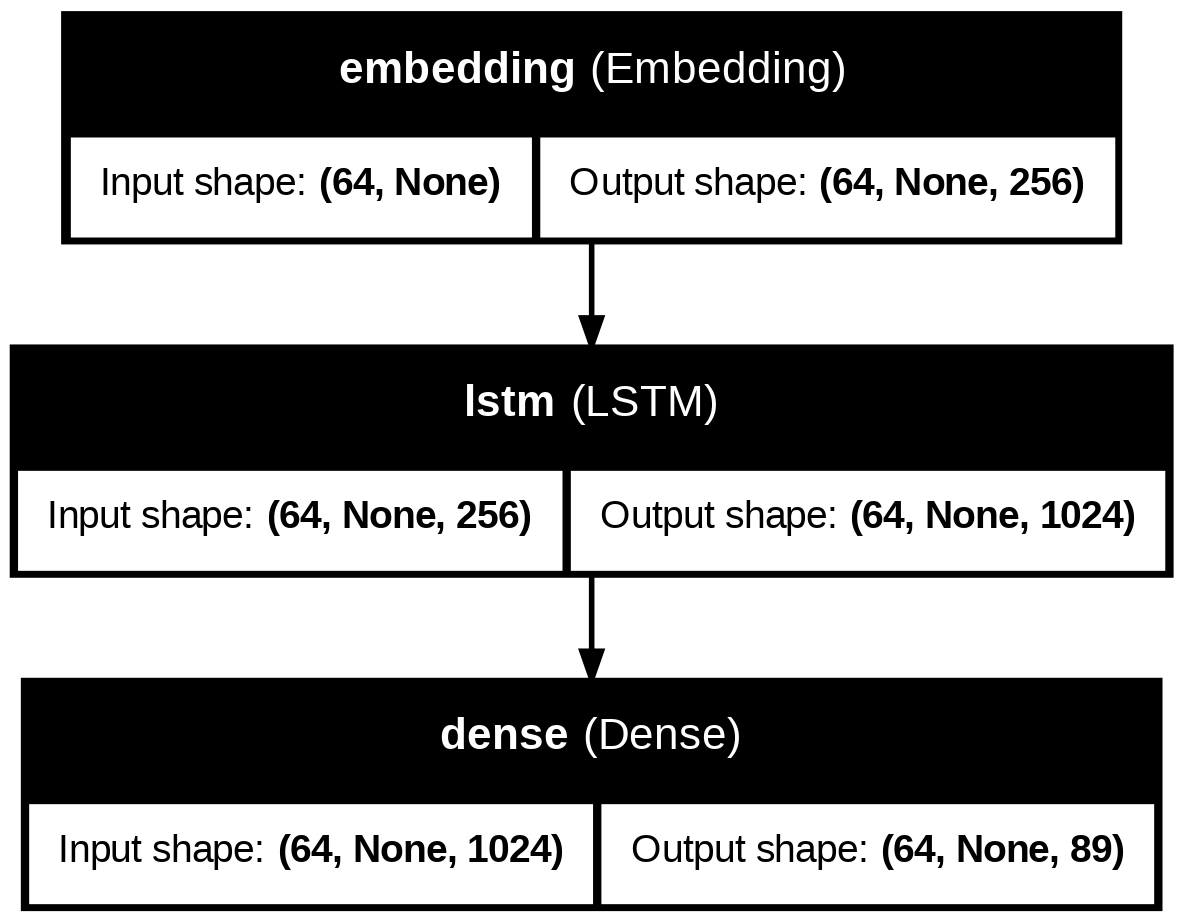

In [20]:
tf.keras.utils.plot_model(
    one_layer_lstm,
    show_shapes=True,
    show_layer_names=True,
)

In [21]:
two_layer_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (64, None, 256)        │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (64, None, 1024)       │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (64, None, 1024)       │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (64, None, 89)         │        91,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,753,689 (52.47 MB)

 Trainable params: 13,753,689 (52.47 MB)

 Non-trainable params: 0 (0.00 B)

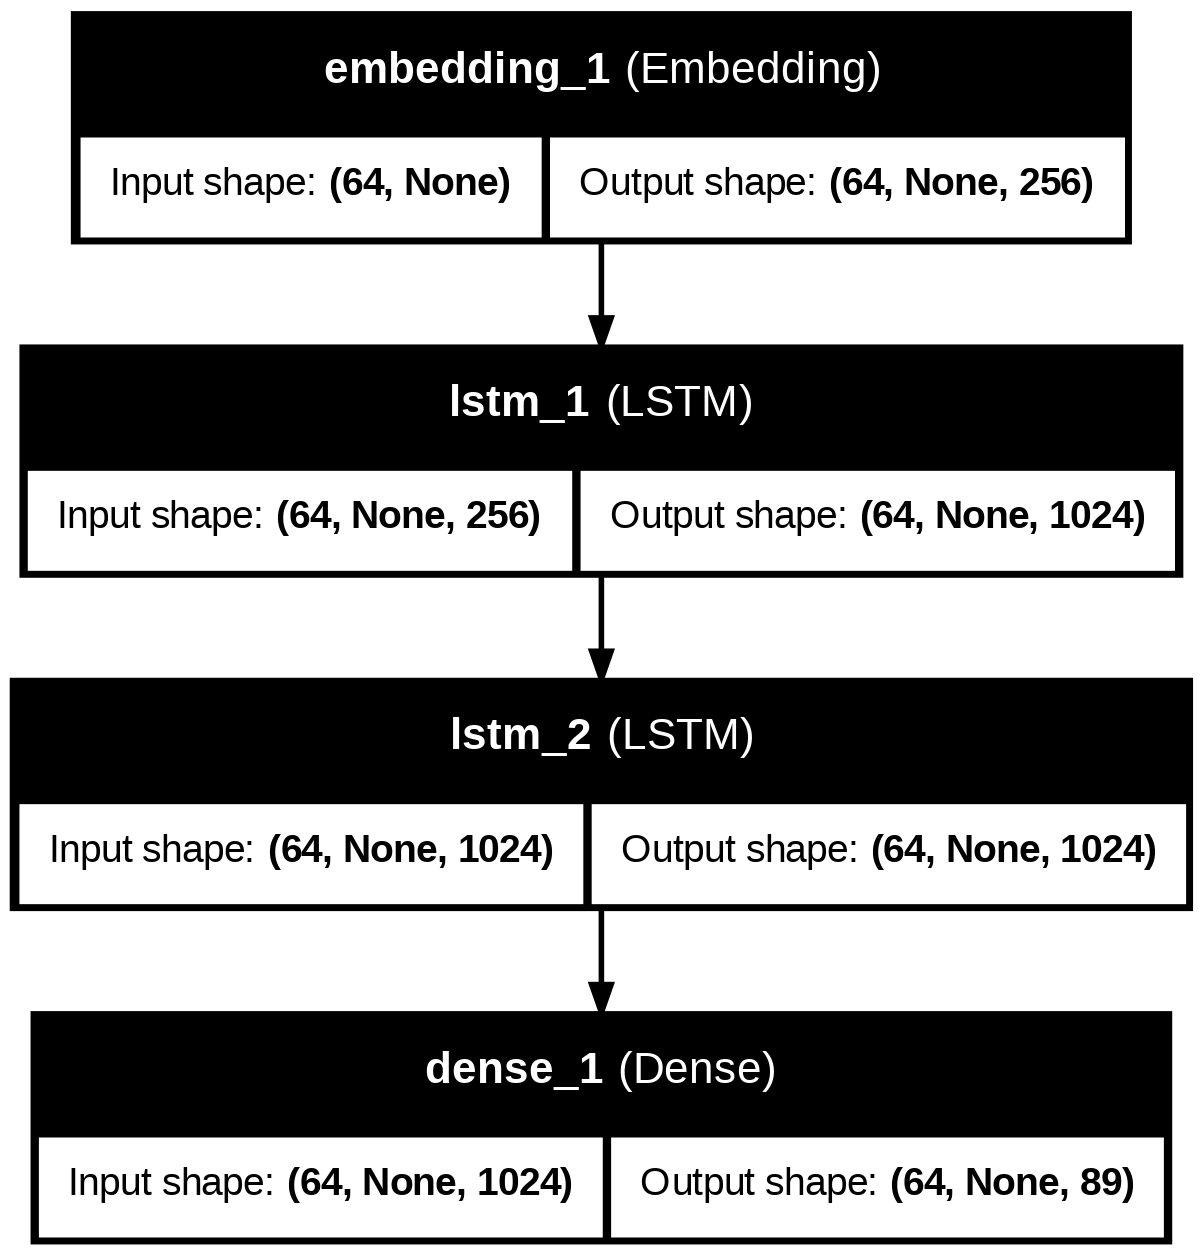

In [22]:
tf.keras.utils.plot_model(
    two_layer_lstm,
    show_shapes=True,
    show_layer_names=True,
)

### Loss Function

In [23]:
def loss(labels, logits):
    """
    Define the loss function for training.
    """
    return tf.keras.losses.sparse_categorical_crossentropy(
        y_true=labels,
        y_pred=logits,
        from_logits=True
    )

### Training Loop

In [24]:
def train_model(model_build, model_name, vocab_size, embedding_dim, rnn_units,
                batch_size, train_dataset, val_dataset, epochs=60, lr=0.001):

  # build model
  model = model_build(vocab_size, embedding_dim, rnn_units, batch_size)

  # compile model
  optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
  model.compile(
        optimizer=optimizer,
        loss=loss
    )

  model.summary()

  # save the model checkpoints
  model_checkpoint_dir = os.path.join(checkpoint_dir, model_name)
  os.makedirs(model_checkpoint_dir, exist_ok=True)
  print(f"Model checkpoints will be saved to: {model_checkpoint_dir}")
  checkpoint_prefix = os.path.join(model_checkpoint_dir, f'{model_name}_epoch_{{epoch:02d}}.weights.h5')

  # save best model
  checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
      filepath=checkpoint_prefix,
      save_best_only=True,
      save_weights_only=True,
      monitor='loss',
      mode='min',
      verbose=1
    )

  # early stopping to prevent overfitting
  early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=3,
        restore_best_weights=True
    )

  history = model.fit(
      x=train_dataset,
      epochs=epochs,
      validation_data=val_dataset,
      callbacks=[
          checkpoint_cb,
          early_stopping
        ]
    )

  # final model
  final_model_path = os.path.join(model_checkpoint_dir, f'{model_name}_final.weights.h5')
  model.save_weights(final_model_path)
  print(f"Final model weights saved to: {final_model_path}")

  return model, history, model_checkpoint_dir

In [25]:
vocab_size = len(char_set)
embedding_dim = 256
rnn_units = 1024
batch_size = 64
epochs = 60
learning_rate = 0.001

In [26]:
one_layer_model, one_layer_history, one_layer_checkpoint = train_model(
    build_One_Layer_LSTM,
    'One-Layer-LSTM',
    vocab_size,
    embedding_dim,
    rnn_units,
    batch_size,
    train_dataset,
    val_dataset,
    epochs=epochs,
    lr = learning_rate
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (64, None, 256)        │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (64, None, 1024)       │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (64, None, 89)         │        91,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,360,985 (20.45 MB)

 Trainable params: 5,360,985 (20.45 MB)

 Non-trainable params: 0 (0.00 B)

Model checkpoints will be saved to: tmp/checkpoints/One-Layer-LSTM
Epoch 1/60
67/69 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 3.2349
Epoch 1: loss improved from inf to 2.79887, saving model to tmp/checkpoints/One-Layer-LSTM/One-Layer-LSTM_epoch_01.weights.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 3.2163 - val_loss: 2.2940
Epoch 2/60
67/69 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.2333
Epoch 2: loss improved from 2.79887 to 2.15311, saving model to tmp/checkpoints/One-Layer-LSTM/One-Layer-LSTM_epoch_02.weights.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 2.2299 - val_loss: 1.9831
Epoch 3/60
67/69 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.9551
Epoch 3: loss improved from 2.15311 to 1.90725, saving model to tmp/checkpoints/One-Layer-LSTM/One-Layer-LSTM_epoch_03.weights.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.9531 - val_loss: 1.7864
Epoch 4/60
67/69 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.7733
Epoch 4: loss improved from 1.90725 to 1.74213, saving model 

In [27]:
two_layer_model, two_layer_history, two_layer_checkpoint = train_model(
    build_Two_Layer_LSTM,
    'Two-Layer-LSTM',
    vocab_size,
    embedding_dim,
    rnn_units,
    batch_size,
    train_dataset,
    val_dataset,
    epochs=epochs,
    lr = learning_rate
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (64, None, 256)        │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (64, None, 1024)       │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (64, None, 1024)       │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (64, None, 89)         │        91,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,753,689 (52.47 MB)

 Trainable params: 13,753,689 (52.47 MB)

 Non-trainable params: 0 (0.00 B)

Model checkpoints will be saved to: tmp/checkpoints/Two-Layer-LSTM
Epoch 1/60
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3.3996
Epoch 1: loss improved from inf to 3.06206, saving model to tmp/checkpoints/Two-Layer-LSTM/Two-Layer-LSTM_epoch_01.weights.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 3.3948 - val_loss: 2.5975
Epoch 2/60
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2.4237
Epoch 2: loss improved from 3.06206 to 2.29774, saving model to tmp/checkpoints/Two-Layer-LSTM/Two-Layer-LSTM_epoch_02.weights.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 2.4219 - val_loss: 2.0660
Epoch 3/60
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 2.0200
Epoch 3: loss improved from 2.29774 to 1.94612, saving model to tmp/checkpoints/Two-Layer-LSTM/Two-Layer-LSTM_epoch_03.weights.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 2.0189 - val_loss: 1.7824
Epoch 4/60
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.7525
Epoch 4: loss improved from 1.94612 to 1.70952, saving model 

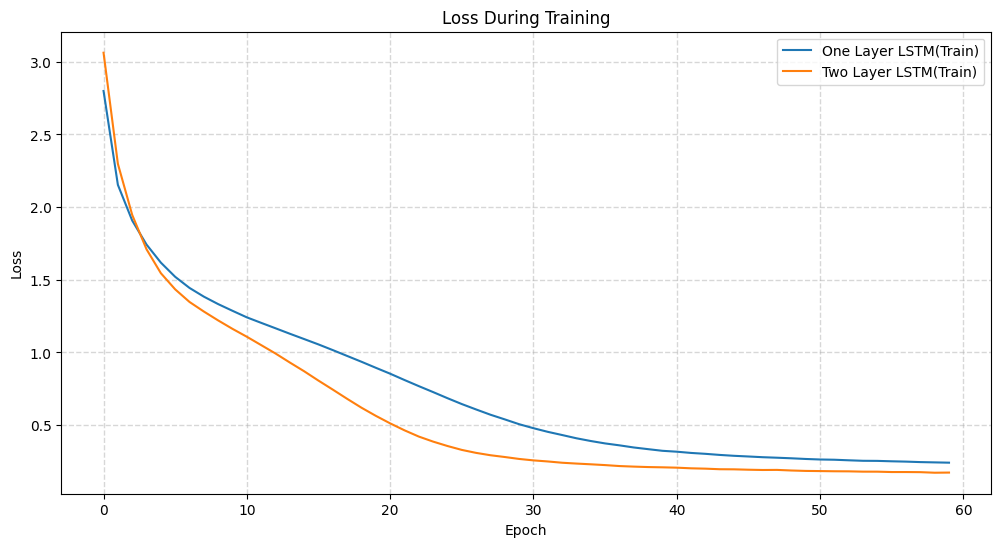

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(one_layer_history.history['loss'], label='One Layer LSTM(Train)')
plt.plot(two_layer_history.history['loss'], label='Two Layer LSTM(Train)')
plt.title('Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(linestyle='--', linewidth=1, alpha=0.5)

plt.savefig('lstm_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation

In [29]:
def generate_text(model_name, start_text, generate_tokens=500, temperature=1.0):
    if model_name == 'One-Layer-LSTM':
        model = build_One_Layer_LSTM(len(char_set), embedding_dim, rnn_units, batch_size=1)
    else:
        model = build_Two_Layer_LSTM(len(char_set), embedding_dim, rnn_units, batch_size=1)

    # find checkpoint directory
    model_dir = os.path.join(checkpoint_dir, model_name)

    weight_files = glob.glob(os.path.join(model_dir, f'{model_name}_epoch_*.weights.h5'))
    if weight_files:
        latest = max(weight_files, key=os.path.getctime)
        # print(f"Loading weights from: {latest}")
        model.load_weights(latest)
    else:
        print(f"No weights found in {model_dir}")
        return start_text

    model.build(tf.TensorShape([1, None]))

    input_indices = [char2int[char] for char in start_text]
    input_indices = tf.expand_dims(input_indices, 0)

    text_generated = []

    # reset states for RNN layers if they are stateful
    for layer in model.layers:
      if hasattr(layer, 'reset_states'):
        layer.reset_states()

    for _ in range(generate_tokens):
        predictions = model(input_indices)

        predictions = predictions / temperature

        # sample from the predictions
        predicted_id = tf.random.categorical(
            tf.expand_dims(predictions[0, -1, :], 0),
            num_samples=1
        )[0, 0].numpy()

        text_generated.append(char_array[predicted_id])

        # update input for next prediction
        input_indices = tf.expand_dims([predicted_id], 0)

    return start_text + ''.join(text_generated)

### One Layer LSTM - Temperature

In [30]:
start_text = "Sherlock Holmes looked at me with a smile. "
temperatures = [0.1, 0.4, 0.7, 1.0]
print("One-Layer LSTM Text Generation varying Temperature:")
print("-" * 50)
for temp in temperatures:
  print(f"\nTemperature: {temp}")
  print("-" * 20)
  generated_text = generate_text(
      model_name='One-Layer-LSTM',
      start_text=start_text,
      generate_tokens=500,
      temperature=temp)
  print(generated_text)

One-Layer LSTM Text Generation varying Temperature:
--------------------------------------------------

Temperature: 0.1
--------------------
Sherlock Holmes looked at me with a smile. I am convinced that the
inspector has formed the opinion of coming into the trough. But he is a professional beggar, though in order to
avoid the police regulations he pretends to a small stump of any chance has
placed in our hands. Let us follow it out to the bitter end. Faces to
the south, the deadly injuries, made. When you
drove him at the side of my bed. He was
a late riser, as a rule, and as the clock on the mantelpiece showed me
that it had indeed been of the greatest importance in cleari

Temperature: 0.4
--------------------
Sherlock Holmes looked at me with a smile. I am convinced now that he is wife.”

“That is a detail which I have tried on my bestomarks of many feet, and the
morning he was still with you, I am lighted to the ground, with the
story part that the house was nearly filled. It wa

### Two Layer LSTM - Temperature

In [31]:
start_text = "Sherlock Holmes looked at me with a smile. "
temperatures = [0.1, 0.4, 0.7, 1.0]
print("Two-Layer LSTM Text Generation varying Temperature:")
print("-" * 50)
for temp in temperatures:
  print(f"\nTemperature: {temp}")
  print("-" * 20)
  generated_text = generate_text(
      model_name='Two-Layer-LSTM',
      start_text=start_text,
      generate_tokens=500,
      temperature=temp)
  print(generated_text)

Two-Layer LSTM Text Generation varying Temperature:
--------------------------------------------------

Temperature: 0.1
--------------------
Sherlock Holmes looked at me with a smile. I am convinced that the
inspector has formed the opinion upon the sofa and the vacuous face, there was something
noble in the simple faith of our visitor which compelled out upon the lamp and let me
expound.”

 “Pray do so.”

“Well, now, in considering this case there are two points about which
I wished to be absolutely clear. We shall now have a little supper and
then retire, the buzz of a few hundred pounds with a limp; but in other
respects he appears to be a powerful and well-nurtured man. S

Temperature: 0.4
--------------------
Sherlock Holmes looked at me with a smile. I am convinced that the
inspector has formed the opinion upon the papers
upon the victim.

“Well, have you solved it?” I asked as I entered.

“Yes. It was the bisulphate of baryta.”

“No, for I have made your statement very clearly.

In [32]:
def generate_text_nucleus(model_name, start_text, generate_tokens=1000, temperature=1.0, p=0.9):
    if model_name == 'One-Layer-LSTM':
        model = build_One_Layer_LSTM(len(char_set), embedding_dim, rnn_units, batch_size=1)
    else:
        model = build_Two_Layer_LSTM(len(char_set), embedding_dim, rnn_units, batch_size=1)

    # find checkpoint directory
    model_dir = os.path.join(checkpoint_dir, model_name)

    weight_files = glob.glob(os.path.join(model_dir, f'{model_name}_epoch_*.weights.h5'))
    if weight_files:
        latest = max(weight_files, key=os.path.getctime)
        # print(f"Loading weights from: {latest}")
        model.load_weights(latest)
    else:
        print(f"No weights found in {model_dir}")
        return start_text

    model.build(tf.TensorShape([1, None]))

    # convert text to vector
    input_indices = [char2int[char] for char in start_text]
    input_indices = tf.expand_dims(input_indices, 0)

    text_generated = []

    # reset states for RNN layers if they are stateful
    for layer in model.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()

    for _ in range(generate_tokens):
        predictions = model(input_indices)

        predictions = predictions / temperature

        pred = predictions[0, -1, :]

        # convert logits to probabilities
        probs = tf.nn.softmax(pred).numpy()

        # sort probabilities in descending order
        sorted_indices = np.argsort(-probs)
        sorted_probs = probs[sorted_indices]

        # calculate cumulative probability
        cumulative_probs = np.cumsum(sorted_probs)

        # find cutoff index where cumulative probability exceeds p
        cutoff_idx = np.argmax(cumulative_probs >= p)

        # include at least the top token if nothing exceeds threshold
        if cutoff_idx == 0 and cumulative_probs[0] < p:
            cutoff_idx = 1

        # get top p-tokens and probability
        top_indices = sorted_indices[:cutoff_idx+1]
        top_probs = sorted_probs[:cutoff_idx+1]

        # renormalize probability
        top_probs = top_probs / np.sum(top_probs)

        # sample from distribution
        predicted_id = np.random.choice(top_indices, size=1, p=top_probs)[0]

        # append
        text_generated.append(char_array[predicted_id])

        # update input for probability
        input_indices = tf.expand_dims([predicted_id], 0)

    return start_text + ''.join(text_generated)

### One Layer LSTM - Nucleus Sampling

In [33]:
start_text = "Sherlock Holmes looked at me with a smile. "

nucleus_samples = [0.1, 0.45, 0.95]
print("One-Layer LSTM Text Generation varying Nucleus Sampling:")
print("-" * 50)
for nucleus in nucleus_samples:
  print(f"\nNucleus Sample: {nucleus}")
  print("-" * 20)
  generated_text = generate_text(
      model_name='One-Layer-LSTM',
      start_text=start_text,
      generate_tokens=500,
      temperature=0.7)
  print(generated_text)

One-Layer LSTM Text Generation varying Nucleus Sampling:
--------------------------------------------------

Nucleus Sample: 0.1
--------------------
Sherlock Holmes looked at me with a smile. I am
am little cry of satisfaction. For a long time he was surely the bell.
Who could come to-night? Some friend of yours, perhaps?”

“Except yourself I have seen him.

“That was under me on the shade of grizzled brown and examined with red-che
and placed in front of him. “Lis
the last square point of view until he had either father from some traces of existence. These little problems help me to do
so.”

“And your easy berrooms as the honeymoon
would be passed by the police to call to-morrow. As

Nucleus Sample: 0.45
--------------------
Sherlock Holmes looked at me with a smile. I
am all streets in dark him and he was gazed and stared down into the
fire. “You see, Mr. Holmes,” said he, “my wife was
standing in the writer, and the evident confust had
set in with exceptional violence. All day the 

### Two Layer LSTM - Nucleus Sampling

In [34]:
nucleus_samples = [0.1, 0.45, 0.95]
print("Two-Layer LSTM Text Generation varying Nucleus Sampling:")
print("-" * 50)
for nucleus in nucleus_samples:
  print(f"\nNucleus Sample: {nucleus}")
  print("-" * 20)
  generated_text = generate_text(
      model_name='Two-Layer-LSTM',
      start_text=start_text,
      generate_tokens=500,
      temperature=0.7)
  print(generated_text)

Two-Layer LSTM Text Generation varying Nucleus Sampling:
--------------------------------------------------

Nucleus Sample: 0.1
--------------------
Sherlock Holmes looked at me with a smile. I am convinced that the
inspector has formed the opinion sight sent a
chill to my own heart. She held up one shaking finger to warn me to be
silent, and she did not give in the least signed the stripped body, has been not very possible that I had ever
seen that her temper was just a little sharp. The incident however, take a small place—a very shiny hat and oppressively respectable
frock-coat.

“Ha! Our party is complete,” said Holmes, “the more readily called back on the old man who is dazed wi

Nucleus Sample: 0.45
--------------------
Sherlock Holmes looked at me with a smile. I am convinced that the
indication has been made up in my life
to the singular case of Miss Mary Sutherland, and to the adventure of
the man with the twisted lip. I then look raise the shattered morost sitting upon the s

In [35]:
def evaluate_spelling_accuracy(generated_text):

    # Initialize spell checker
    spell = SpellChecker(language='en')

    # Clean the text and split into words
    cleaned_text = re.sub(r'[^\w\s]', ' ', generated_text.lower())
    words = [word for word in cleaned_text.split() if word.strip()]

    words = [word for word in words if word.isalpha() and len(word) > 1]

    # Count total words
    total_words = len(words)

    if total_words == 0:
        return {
            "correct_words": 0,
            "incorrect_words": 0,
            "total_words": 0,
            "spelling_accuracy": 0.0,
            "most_common_incorrect": []
        }

    # Find misspelled words
    misspelled = spell.unknown(words)

    # Count correct words
    correct_words = total_words - len(misspelled)

    # Calculate spelling accuracy
    spelling_accuracy = (correct_words / total_words) * 100

    # Get most common incorrect words
    incorrect_counter = Counter(misspelled)
    most_common_incorrect = incorrect_counter.most_common(10)

    # Return metrics
    return {
        "correct_words": correct_words,
        "incorrect_words": len(misspelled),
        "total_words": total_words,
        "spelling_accuracy": spelling_accuracy,
        "most_common_incorrect": most_common_incorrect
    }

In [36]:
def analyze_text(text, original_prompt_length):
    # Analyze only the generated portion
    generated_text = text[original_prompt_length:]

    # Word diversity (higher = more diverse vocabulary)
    words = re.findall(r'\b\w+\b', generated_text.lower())
    word_diversity = len(set(words)) / len(words) if words else 0

    # Repetition rate (higher = more repetition)
    word_counts = Counter(words)
    repetitions = sum(count - 1 for count in word_counts.values())
    repetition_rate = repetitions / len(words) if words else 0

    # Average sentence length
    sentences = re.split(r'[.!?]+', generated_text)
    sentences = [s for s in sentences if s.strip()]
    avg_sentence_length = sum(len(s.split()) for s in sentences) / len(sentences) if sentences else 0

    # Spelling accuracy
    spelling_accuracy = evaluate_spelling_accuracy(generated_text)['spelling_accuracy']

    return {
        "word_diversity": word_diversity,
        "repetition_rate": repetition_rate,
        "avg_sentence_length": avg_sentence_length,
        "spelling_accuracy" : spelling_accuracy
    }

## Complete Evaluation

In [42]:
print("\n===== SUMMARY OF RESULTS =====")
print(f"{'Model':<15} {'Sampling':<10} {'Temp':<6} {'Nucleus':<8} {'Word Div':<10} {'Spelling':<10}")
print("-" * 65)

nuclear_samples = [0.7, 0.8, 0.9, 0.95]
temperatures = [0.2, 0.5, 0.7, 1.0, 1.3, 1.7, 2.0]

results = []

# one layer lstm
for temp in temperatures:
  text = generate_text(
      model_name='One-Layer-LSTM',
      start_text=start_text,
      generate_tokens=500,
      temperature=temp
      )
  metrics = analyze_text(text, len(start_text))
  print(f"{'One-Layer-LSTM':<15} {'Regular':<10} {temp:<6.1f} {'N/A':<8} "
          f"{metrics['word_diversity']:<10.3f} {metrics['spelling_accuracy']:<10.2f}")
  text = generate_text(
      model_name='Two-Layer-LSTM',
      start_text=start_text,
      generate_tokens=500,
      temperature=temp
      )
  metrics = analyze_text(text, len(start_text))
  print(f"{'Two-Layer-LSTM':<15} {'Regular':<10} {temp:<6.1f} {'N/A':<8} "
  f"{metrics['word_diversity']:<10.3f} {metrics['spelling_accuracy']:<10.2f}")

# # 2 layer lstm
# for temp in temperatures:
#   text = generate_text(
#       model_name='Two-Layer-LSTM',
#       start_text=start_text,
#       generate_tokens=500,
#       temperature=temp
#       )
#   metrics = analyze_text(text, len(start_text))
#   print(f"{'Two-Layer-LSTM':<15} {'Regular':<10} {temp:<6.1f} {'N/A':<8} "
#   f"{metrics['word_diversity']:<10.3f} {metrics['spelling_accuracy']:<10.2f}")



===== SUMMARY OF RESULTS =====
Model           Sampling   Temp   Nucleus  Word Div   Spelling  
-----------------------------------------------------------------
One-Layer-LSTM  Regular    0.2    N/A      0.762      100.00    
Two-Layer-LSTM  Regular    0.2    N/A      0.763      100.00    
One-Layer-LSTM  Regular    0.5    N/A      0.723      97.78     
Two-Layer-LSTM  Regular    0.5    N/A      0.724      97.85     
One-Layer-LSTM  Regular    0.7    N/A      0.683      95.70     
Two-Layer-LSTM  Regular    0.7    N/A      0.758      94.51     
One-Layer-LSTM  Regular    1.0    N/A      0.768      91.40     
Two-Layer-LSTM  Regular    1.0    N/A      0.687      92.22     
One-Layer-LSTM  Regular    1.3    N/A      0.828      86.36     
Two-Layer-LSTM  Regular    1.3    N/A      0.745      94.32     
One-Layer-LSTM  Regular    1.7    N/A      0.800      82.29     
Two-Layer-LSTM  Regular    1.7    N/A      0.811      73.17     
One-Layer-LSTM  Regular    2.0    N/A      0.905      61.

In [ ]:
print("\n===== SUMMARY OF RESULTS =====")
print(f"{'Model':<15} {'Sampling':<10} {'Temp':<6} {'Nucleus':<8} {'Word Div':<10} {'Spelling':<10}")
print("-" * 65)
temperatures = [0.2, 0.5, 0.7, 1.0, 1.3, 1.7, 2.0]
nuclear_samples = [0.7, 0.8, 0.9, 0.95]

results = []

# one layer lstm
for temps in temperatures:
  for p in nucleus_samples:
    text = generate_text_nucleus(
        model_name='One-Layer-LSTM',
        start_text=start_text,
        generate_tokens=500,
        temperature=temps,
        p=p)
    metrics = analyze_text(text, len(start_text))
    print(f"{'One-Layer-LSTM':<15} {'Nucleus':<10} {temp:<6.1f} {p:<8.1f} "
    f"{metrics['word_diversity']:<10.3f} {metrics['spelling_accuracy']:<10.2f}")

    text = generate_text_nucleus(
        model_name='Two-Layer-LSTM',
        start_text=start_text,
        generate_tokens=500,
        temperature=temps,
        p=p)
    metrics = analyze_text(text, len(start_text))
    print(f"{'Two-Layer-LSTM':<15} {'Nucleus':<10} {temp:<6.1f} {p:<8.1f} "
    f"{metrics['word_diversity']:<10.3f} {metrics['spelling_accuracy']:<10.2f}")


===== SUMMARY OF RESULTS =====
Model           Sampling   Temp   Nucleus  Word Div   Spelling  
-----------------------------------------------------------------
One-Layer-LSTM  Nucleus    0.2    0.1      0.774      96.63     
Two-Layer-LSTM  Nucleus    0.2    0.1      0.703      98.94     
One-Layer-LSTM  Nucleus    0.2    0.5      0.774      96.63     
Two-Layer-LSTM  Nucleus    0.2    0.5      0.703      98.94     
One-Layer-LSTM  Nucleus    0.2    0.9      0.753      93.51     
Two-Layer-LSTM  Nucleus    0.2    0.9      0.767      96.39     
One-Layer-LSTM  Nucleus    0.2    0.1      0.774      96.63     
Two-Layer-LSTM  Nucleus    0.2    0.1      0.703      98.94     
One-Layer-LSTM  Nucleus    0.2    0.5      0.713      98.86     


In [ ]:
# import re

# start_string = "Sherlock Holmes looked at me with a smile. "
# # Generate 5 samples for more reliable metrics
# metrics = []
# for _ in range(5):
#     text = generate_text(model, start_string, 300, 1.0)
#     metrics.append(analyze_text(text, len(start_string)))

# # Average the metrics
# results = {k: sum(m[k] for m in metrics)/len(metrics) for k in metrics[0]}

In [ ]:
# # Print the results
# print(f"{'Temperature':<12} {'Word Diversity':<18} {'Repetition Rate':<18} {'Avg Sentence Length':<24} {'Spelling accuracy'}")
# print("-" * 100)
# temp = 1.0
# print(f"{temp:<12} {results['word_diversity']:<18.3f} {results['repetition_rate']:<18.3f} {results['avg_sentence_length']:<24.3f} {results['spelling_accuracy']:0.2f}")